In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import requests
from bs4 import BeautifulSoup
from urllib.request import urlopen
import os
import time
from unidecode import unidecode
import warnings
from mplsoccer.pitch import Pitch
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import VerticalPitch
from PIL import Image

In [2]:
match_html_path = r"C:\Users\K Raghunandan\Analyst\Matches\Manchester United 3-1 Aston Villa - Premier League 2025_2026 Live.html"
fotmob_matchId = 4813671

def extract_json_from_html(html_path, save_output=False):
    with open(html_path, 'r', encoding='utf-8') as html_file:
        html = html_file.read()

    regex_pattern = r'(?<=require\.config\.params\["args"\].=.)[\s\S]*?;'
    data_txt = re.findall(regex_pattern, html)[0]

    # add quotations for JSON parser
    data_txt = data_txt.replace('matchId', '"matchId"')
    data_txt = data_txt.replace('matchCentreData', '"matchCentreData"')
    data_txt = data_txt.replace('matchCentreEventTypeJson', '"matchCentreEventTypeJson"')
    data_txt = data_txt.replace('formationIdNameMappings', '"formationIdNameMappings"')
    data_txt = data_txt.replace('};', '}')

    if save_output:
        # save JSON data to txt
        output_file = open(f"{html_path}.txt", "wt", encoding='utf-8')
        n = output_file.write(data_txt)
        output_file.close()

    return data_txt

def extract_data_from_dict(data):
    # load data from json
    event_types_json = data["matchCentreEventTypeJson"]
    formation_mappings = data["formationIdNameMappings"]
    events_dict = data["matchCentreData"]["events"]
    teams_dict = {data["matchCentreData"]['home']['teamId']: data["matchCentreData"]['home']['name'],
                  data["matchCentreData"]['away']['teamId']: data["matchCentreData"]['away']['name']}
    players_dict = data["matchCentreData"]["playerIdNameDictionary"]
    # create players dataframe
    players_home_df = pd.DataFrame(data["matchCentreData"]['home']['players'])
    players_home_df["teamId"] = data["matchCentreData"]['home']['teamId']
    players_away_df = pd.DataFrame(data["matchCentreData"]['away']['players'])
    players_away_df["teamId"] = data["matchCentreData"]['away']['teamId']
    players_df = pd.concat([players_home_df, players_away_df])
    players_ids = data["matchCentreData"]["playerIdNameDictionary"]
    return events_dict, players_df, teams_dict

def get_short_name(full_name):
    if pd.isna(full_name):
        return full_name
    parts = full_name.split()
    if len(parts) == 1:
        return full_name  # No need for short name if there's only one word
    elif len(parts) == 2:
        return parts[0][0] + ". " + parts[1]
    else:
        return parts[0][0] + ". " + parts[1][0] + ". " + " ".join(parts[2:])

json_data_txt = extract_json_from_html(match_html_path)
data = json.loads(json_data_txt)
events_dict, players_df, teams_dict = extract_data_from_dict(data)

df = pd.DataFrame(events_dict)
dfp = pd.DataFrame(players_df)
dfp['shortName'] = dfp['name'].apply(get_short_name)

In [3]:
df['type'] = df['type'].str.extract(r"'displayName': '([^']+)")
df['outcomeType'] = df['outcomeType'].str.extract(r"'displayName': '([^']+)")
df['period'] = df['period'].str.extract(r"'displayName': '([^']+)")

In [4]:
df['teamName'] = df['teamId'].map(teams_dict)
team_names = list(teams_dict.values())
opposition_dict = {team_names[i]: team_names[1-i] for i in range(len(team_names))}
df['oppositionTeamName'] = df['teamName'].map(opposition_dict)

In [5]:
df['x'] = df['x']*1.2
df['y'] = df['y']*0.8
df['endX'] = df['endX']*1.2
df['endY'] = df['endY']*0.8
df['goalMouthY'] = df['goalMouthY']*0.8

In [6]:
columns_to_drop = ['height', 'weight', 'age', 'isManOfTheMatch', 'field', 'stats', 
                   'subbedInPlayerId', 'subbedOutPeriod', 
                   'subbedOutExpandedMinute', 'subbedInPeriod', 'subbedInExpandedMinute', 'subbedOutPlayerId', 
                   'teamId']
dfp.drop(columns=columns_to_drop, inplace=True)

In [7]:
df

,id,eventId,minute,second,teamId,x,y,expandedMinute,period,type,...,relatedPlayerId,blockedX,blockedY,goalMouthZ,goalMouthY,isShot,cardType,isGoal,teamName,oppositionTeamName
0,2.911972e+09,3,0,0.0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Aston Villa
1,2.911972e+09,3,0,0.0,24,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aston Villa,Man Utd
2,2.911972e+09,4,0,0.0,24,60.00,40.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aston Villa,Man Utd
3,2.911972e+09,5,0,5.0,24,23.76,32.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aston Villa,Man Utd
4,2.912162e+09,791,0,8.0,24,36.60,3.68,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aston Villa,Man Utd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1473,2.912105e+09,824,98,9.0,32,0.00,0.00,100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Aston Villa
1474,2.912106e+09,789,0,0.0,24,0.00,0.00,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aston Villa,Man Utd
1475,2.912105e+09,825,0,0.0,32,0.00,0.00,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Aston Villa
1476,2.911909e+09,2,0,0.0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Aston Villa


In [8]:
dfp

,playerId,shirtNo,name,position,isFirstEleven,shortName
0,402184,31,Senne Lammens,GK,True,S. Lammens
1,353418,2,Diogo Dalot,DR,True,D. Dalot
2,437299,15,Leny Yoro,DC,True,L. Yoro
3,99487,5,Harry Maguire,DC,True,H. Maguire
4,118244,23,Luke Shaw,DL,True,L. Shaw
5,88526,18,Casemiro,DMC,True,Casemiro
6,460260,37,Kobbie Mainoo,DMC,True,K. Mainoo
7,386634,16,Amad Diallo,AMR,True,A. Diallo
8,123761,8,Bruno Fernandes,AMC,True,B. Fernandes
9,362758,10,Matheus Cunha,AML,True,M. Cunha


In [9]:
df = df.merge(dfp, on='playerId', how='left')

In [10]:
df = df[
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['endX'].notna()) & 
    (df['endY'].notna())) | 
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['goalMouthY'].notna()))
]

In [11]:
df=df.reset_index()

In [12]:
df

,index,id,eventId,minute,second,teamId,x,y,expandedMinute,period,...,isShot,cardType,isGoal,teamName,oppositionTeamName,shirtNo,name,position,isFirstEleven,shortName
0,2,2.911972e+09,4,0,0.0,24,60.00,40.00,0,NaN,...,NaN,NaN,NaN,Aston Villa,Man Utd,7.0,John McGinn,AMC,True,J. McGinn
1,3,2.911972e+09,5,0,5.0,24,23.76,32.00,0,NaN,...,NaN,NaN,NaN,Aston Villa,Man Utd,23.0,Emiliano Martínez,GK,True,E. Martínez
2,4,2.912162e+09,791,0,8.0,24,36.60,3.68,0,NaN,...,NaN,NaN,NaN,Aston Villa,Man Utd,26.0,Lamare Bogarde,DR,True,L. Bogarde
3,7,2.911973e+09,5,0,52.0,32,34.68,66.96,0,NaN,...,NaN,NaN,NaN,Man Utd,Aston Villa,31.0,Senne Lammens,GK,True,S. Lammens
4,10,2.911973e+09,8,0,54.0,24,34.92,19.04,0,NaN,...,NaN,NaN,NaN,Aston Villa,Man Utd,6.0,Ross Barkley,DMC,True,R. Barkley
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064,1465,2.912104e+09,783,97,55.0,24,70.80,28.64,99,NaN,...,NaN,NaN,NaN,Aston Villa,Man Utd,27.0,Morgan Rogers,AMR,True,M. Rogers
1065,1467,2.912105e+09,784,98,1.0,24,101.76,14.64,100,NaN,...,NaN,NaN,NaN,Aston Villa,Man Utd,16.0,Andrés García,Sub,NaN,A. García
1066,1468,2.912105e+09,785,98,4.0,24,85.68,21.12,100,NaN,...,NaN,NaN,NaN,Aston Villa,Man Utd,24.0,Amadou Onana,DMC,True,A. Onana
1067,1469,2.912105e+09,821,98,5.0,32,14.16,37.76,100,NaN,...,NaN,NaN,NaN,Man Utd,Aston Villa,2.0,Diogo Dalot,DR,True,D. Dalot


In [13]:
df=df[["minute","second","x","y","endX","endY","teamName","shirtNo","position","shortName","goalMouthY","isShot","isGoal"]]

In [14]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,60.00,40.00,24.84,40.24,Aston Villa,7.0,AMC,J. McGinn,NaN,NaN,NaN
1,0,5.0,23.76,32.00,39.48,4.48,Aston Villa,23.0,GK,E. Martínez,NaN,NaN,NaN
2,0,8.0,36.60,3.68,86.28,8.08,Aston Villa,26.0,DR,L. Bogarde,NaN,NaN,NaN
3,0,52.0,34.68,66.96,85.08,60.96,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
4,0,54.0,34.92,19.04,45.96,31.76,Aston Villa,6.0,DMC,R. Barkley,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064,97,55.0,70.80,28.64,93.00,6.64,Aston Villa,27.0,AMR,M. Rogers,NaN,NaN,NaN
1065,98,1.0,101.76,14.64,85.68,21.12,Aston Villa,16.0,Sub,A. García,NaN,NaN,NaN
1066,98,4.0,85.68,21.12,106.32,45.28,Aston Villa,24.0,DMC,A. Onana,NaN,NaN,NaN
1067,98,5.0,14.16,37.76,26.88,51.92,Man Utd,2.0,DR,D. Dalot,NaN,NaN,NaN


In [16]:
team1=df[df["teamName"]=="Man Utd"]
team1

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
3,0,52.0,34.68,66.96,85.08,60.96,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
5,0,56.0,76.08,60.24,97.92,56.88,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN
8,1,2.0,65.76,42.96,75.12,80.00,Man Utd,2.0,DR,D. Dalot,NaN,NaN,NaN
10,1,19.0,54.12,72.96,84.48,42.08,Man Utd,5.0,DC,H. Maguire,NaN,NaN,NaN
12,1,28.0,32.64,17.84,40.44,19.76,Man Utd,2.0,DR,D. Dalot,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056,97,25.0,41.88,27.68,39.24,44.24,Man Utd,25.0,Sub,M. Ugarte,NaN,NaN,NaN
1057,97,31.0,26.64,31.52,53.76,18.80,Man Utd,5.0,DC,H. Maguire,NaN,NaN,NaN
1063,97,44.0,4.92,48.24,39.12,73.20,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN
1067,98,5.0,14.16,37.76,26.88,51.92,Man Utd,2.0,DR,D. Dalot,NaN,NaN,NaN


In [17]:
team2=df[df["teamName"]=="Aston Villa"]
team2

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,60.00,40.00,24.84,40.24,Aston Villa,7.0,AMC,J. McGinn,NaN,NaN,NaN
1,0,5.0,23.76,32.00,39.48,4.48,Aston Villa,23.0,GK,E. Martínez,NaN,NaN,NaN
2,0,8.0,36.60,3.68,86.28,8.08,Aston Villa,26.0,DR,L. Bogarde,NaN,NaN,NaN
4,0,54.0,34.92,19.04,45.96,31.76,Aston Villa,6.0,DMC,R. Barkley,NaN,NaN,NaN
6,0,59.0,24.36,30.80,46.44,31.12,Aston Villa,5.0,DC,T. Mings,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1061,97,39.0,107.28,42.64,115.32,32.24,Aston Villa,18.0,Sub,T. Abraham,NaN,NaN,NaN
1062,97,42.0,117.24,30.24,113.88,30.24,Aston Villa,21.0,Sub,D. Luiz,NaN,NaN,NaN
1064,97,55.0,70.80,28.64,93.00,6.64,Aston Villa,27.0,AMR,M. Rogers,NaN,NaN,NaN
1065,98,1.0,101.76,14.64,85.68,21.12,Aston Villa,16.0,Sub,A. García,NaN,NaN,NaN


In [18]:
firstSub1=75

In [19]:
team1=team1[team1["minute"]<firstSub1]
team1

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
3,0,52.0,34.68,66.96,85.08,60.96,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
5,0,56.0,76.08,60.24,97.92,56.88,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN
8,1,2.0,65.76,42.96,75.12,80.00,Man Utd,2.0,DR,D. Dalot,NaN,NaN,NaN
10,1,19.0,54.12,72.96,84.48,42.08,Man Utd,5.0,DC,H. Maguire,NaN,NaN,NaN
12,1,28.0,32.64,17.84,40.44,19.76,Man Utd,2.0,DR,D. Dalot,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,73,30.0,51.24,68.96,44.64,52.80,Man Utd,23.0,DL,L. Shaw,NaN,NaN,NaN
835,73,31.0,46.08,50.88,110.88,2.24,Man Utd,5.0,DC,H. Maguire,NaN,NaN,NaN
837,74,21.0,63.48,0.00,90.96,6.56,Man Utd,2.0,DR,D. Dalot,NaN,NaN,NaN
838,74,29.0,90.36,4.64,85.44,13.44,Man Utd,19.0,FW,B. Mbeumo,NaN,NaN,NaN


In [20]:
firstSub2=60

In [21]:
team2=team2[team2["minute"]<firstSub2]
team2

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,60.00,40.00,24.84,40.24,Aston Villa,7.0,AMC,J. McGinn,NaN,NaN,NaN
1,0,5.0,23.76,32.00,39.48,4.48,Aston Villa,23.0,GK,E. Martínez,NaN,NaN,NaN
2,0,8.0,36.60,3.68,86.28,8.08,Aston Villa,26.0,DR,L. Bogarde,NaN,NaN,NaN
4,0,54.0,34.92,19.04,45.96,31.76,Aston Villa,6.0,DMC,R. Barkley,NaN,NaN,NaN
6,0,59.0,24.36,30.80,46.44,31.12,Aston Villa,5.0,DC,T. Mings,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,57,54.0,66.72,11.20,88.68,2.08,Aston Villa,24.0,DMC,A. Onana,NaN,NaN,NaN
704,57,59.0,84.48,5.12,90.72,18.40,Aston Villa,27.0,AMR,M. Rogers,NaN,NaN,NaN
705,58,0.0,90.72,18.40,82.80,19.68,Aston Villa,7.0,AMC,J. McGinn,NaN,NaN,NaN
706,59,34.0,84.72,18.72,112.92,42.24,Aston Villa,7.0,AMC,J. McGinn,NaN,NaN,NaN


In [22]:
response=requests.get("https://www.sofascore.com/football/match/aston-villa-manchester-united/KP#id:14023994,tab:statistics")

In [23]:
soup=BeautifulSoup(response.text,"html.parser")

In [24]:
soup.select('g[cursor="pointer"]')

[]

In [25]:
headers = {
    'accept': '*/*',
    'accept-language': 'en-US,en;q=0.9,hi;q=0.8',
    'referer': 'https://www.sofascore.com/football/match/aston-villa-manchester-united/KP',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36',
}

url='https://www.sofascore.com/api/v1/event/14023994/shotmap'

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [26]:
shots=response.json()

In [27]:
df_shots=pd.json_normalize(shots["shotmap"])

In [28]:
df_shots

,isHome,shotType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,addedTime,...,draw.end.y,draw.goal.x,draw.goal.y,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,goalkeeper.sofascoreId,draw.block.x,draw.block.y,goalType
0,False,miss,set-piece,right-foot,left,0.034046,0.000000,6895263,90,7.0,...,0,40.3,80.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,block,assisted,left-foot,low-centre,0.034887,0.000000,6895256,90,6.0,...,0,48.6,81.0,13.4,34.8,0.0,EmiMartínez,34.8,13.4,NaN
2,True,miss,fast-break,right-foot,right,0.239789,0.000000,6895170,85,NaN,...,0,72.4,98.6,NaN,NaN,NaN,EmiMartínez,NaN,NaN,NaN
3,True,goal,regular,right-foot,low-left,0.075159,0.508013,6895105,81,NaN,...,0,47.2,81.0,NaN,NaN,NaN,EmiMartínez,NaN,NaN,regular
4,True,goal,assisted,right-foot,low-right,0.177168,0.471050,6895033,71,NaN,...,0,52.7,93.0,NaN,NaN,NaN,EmiMartínez,NaN,NaN,regular
5,False,goal,corner,left-foot,low-left,0.113119,0.526625,6894999,64,NaN,...,0,47.2,93.0,NaN,NaN,NaN,NaN,NaN,NaN,regular
6,False,save,regular,right-foot,high-centre,0.192288,0.467487,6894968,63,NaN,...,0,51.6,69.6,2.3,53.8,0.0,NaN,53.8,2.3,NaN
7,False,miss,assisted,head,right,0.038977,0.000000,6894970,63,NaN,...,0,61.2,84.7,9.4,56.1,0.0,NaN,56.1,9.4,NaN
8,True,save,assisted,other,high-centre,0.057339,0.035150,6894956,62,NaN,...,0,50.0,76.6,4.0,55.8,0.0,EmiMartínez,55.8,4.0,NaN
9,False,miss,set-piece,head,right,0.361109,0.000000,6894837,60,NaN,...,0,61.8,69.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df_shots=df_shots.sort_values("time").reset_index()
df_shots

,index,isHome,shotType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,...,draw.end.y,draw.goal.x,draw.goal.y,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,goalkeeper.sofascoreId,draw.block.x,draw.block.y,goalType
0,24,False,miss,assisted,head,left,0.138024,0.000000,6894174,9,...,0,24.2,98.6,5.0,34.8,0.0,NaN,34.8,5.0,NaN
1,23,True,block,assisted,left-foot,low-centre,0.023962,0.000000,6894186,20,...,0,49.6,81.0,18.2,57.8,0.0,EmiMartínez,57.8,18.2,NaN
2,22,True,save,corner,head,low-left,0.043422,0.483603,6894202,22,...,0,46.6,92.4,1.2,52.0,0.0,EmiMartínez,52.0,1.2,NaN
3,21,False,miss,assisted,left-foot,high-right,0.059158,0.000000,6894214,24,...,0,63.0,59.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20,True,miss,corner,left-foot,left,0.031802,0.000000,6894340,35,...,0,6.4,94.4,1.9,9.4,0.0,EmiMartínez,9.4,1.9,NaN
5,19,True,block,assisted,right-foot,low-centre,0.043655,0.000000,6894351,37,...,0,49.5,81.0,13.7,63.5,0.0,EmiMartínez,63.5,13.7,NaN
6,18,True,miss,assisted,left-foot,high,0.107062,0.000000,6894355,38,...,0,45.5,26.4,NaN,NaN,NaN,EmiMartínez,NaN,NaN,NaN
7,17,True,miss,fast-break,right-foot,right,0.026354,0.000000,6894437,43,...,0,61.2,91.7,NaN,NaN,NaN,EmiMartínez,NaN,NaN,NaN
8,16,True,miss,assisted,right-foot,high-right,0.047915,0.000000,6894660,48,...,0,60.0,34.7,NaN,NaN,NaN,EmiMartínez,NaN,NaN,NaN
9,15,True,block,assisted,right-foot,low-left,0.030014,0.000000,6894682,51,...,0,48.0,81.0,14.7,63.7,0.0,EmiMartínez,63.7,14.7,NaN


In [30]:
df_shots=df_shots[["isHome","shotType","xg","time","player.shortName","player.jerseyNumber","playerCoordinates.x","playerCoordinates.y",
        "goalMouthCoordinates.x","goalMouthCoordinates.y"]]

In [31]:
df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
df_shots["goalMouthCoordinates.x"]=df_shots["goalMouthCoordinates.x"]*1.2
df_shots["goalMouthCoordinates.y"]=df_shots["goalMouthCoordinates.y"]*0.8

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_16568\3668136620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_16568\3668136620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_16568\3668136620.py:3: SettingWithCopyWarning: 
A value is trying to be set on a c

In [32]:
for x in range(len(df_shots["playerCoordinates.x"])):
    if (df_shots["isHome"][x]==False):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
    if (df_shots["isHome"][x]==True):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_16568\4112479664.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
C:\Users\K Raghunandan\AppData\Local\Temp\ipy

In [33]:
team1_shots=df_shots[df_shots["isHome"]==True]
team1_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
1,True,block,0.023962,20,B. Fernandes,8,32.76,30.56,0.0,40.32
2,True,save,0.043422,22,A. Diallo,16,10.92,34.40,0.0,42.72
4,True,miss,0.031802,35,B. Mbeumo,19,24.24,29.04,0.0,74.88
5,True,block,0.043655,37,Casemiro,18,19.80,26.88,0.0,40.40
6,True,miss,0.107062,38,D. Dalot,2,13.32,30.24,0.0,43.60
7,True,miss,0.026354,43,B. Fernandes,8,31.32,55.04,0.0,31.04
8,True,miss,0.047915,48,A. Diallo,16,13.44,21.92,0.0,32.00
9,True,block,0.030014,51,B. Fernandes,8,23.64,24.80,0.0,41.60
10,True,miss,0.043458,51,M. Cunha,10,25.56,49.04,0.0,49.36
11,True,save,0.052555,52,B. Mbeumo,19,17.76,54.72,0.0,39.60


In [34]:
team2_shots=df_shots[df_shots["isHome"]==False]
team2_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,False,miss,0.138024,9,E. Buendía,10,8.40,37.52,0.0,60.64
3,False,miss,0.059158,24,J. McGinn,7,23.16,46.48,0.0,29.60
13,False,block,0.024669,54,M. Rogers,27,11.76,20.88,0.0,40.80
14,False,block,0.048039,57,E. Buendía,10,32.28,41.20,0.0,40.40
15,False,miss,0.361109,60,T. Mings,5,7.08,42.24,0.0,30.56
17,False,miss,0.038977,63,L. Bailey,31,14.04,40.96,0.0,31.04
18,False,save,0.192288,63,A. Onana,24,11.76,32.96,0.0,38.72
19,False,goal,0.113119,64,R. Barkley,6,12.72,34.00,0.0,42.24
24,False,miss,0.034046,90,M. Rogers,27,28.20,43.12,0.0,47.76


In [35]:
a_xG=[0]
h_xG=[0]
a_min=[0]
h_min=[0]

for x in range(len(df_shots["playerCoordinates.x"])):
    if (df_shots["isHome"][x]==True):
        h_xG.append(df_shots["xg"][x])
        h_min.append(df_shots["time"][x])
    if (df_shots["isHome"][x]==False):
        a_xG.append(df_shots["xg"][x])
        a_min.append(df_shots["time"][x])

In [37]:
def nums_cumulative_sum(nums_list):
    return [sum(nums_list[:i+1]) for i in range(len(nums_list))]

a_cum=nums_cumulative_sum(a_xG)
h_cum=nums_cumulative_sum(h_xG)

In [38]:
a_total=round(a_cum[-1],2)
h_total=round(h_cum[-1],2)

In [39]:
def create_passnetwork(df, ax,color):
    df["passer"]=df["shirtNo"]
    df["recipient"]=df["shirtNo"].shift(-1)

    pas=pd.to_numeric(df["passer"],downcast="integer")
    rec=pd.to_numeric(df["recipient"],downcast="integer")

    df["passer"]=pas
    df["recipient"]=rec

    df=df.drop(["goalMouthY","isShot","isGoal"],axis=1)

    average_locations=df.groupby("passer").agg({"x":["mean"],"y":["mean","count"]})
    average_locations.columns=["x","y","count"]
    average_locations

    pass_between = (
    df
    .groupby(["passer", "recipient"])
    .size()
    .reset_index(name="pass_count")
    )

    pass_between = pass_between.merge(average_locations, left_on='passer', right_index=True)
    pass_between = pass_between.merge(average_locations, left_on='recipient', right_index=True, suffixes=['', '_end'])

    pass_between=pass_between[pass_between["pass_count"]>3]

    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A')
    pitch.draw(ax=ax)
    plt.gca().invert_xaxis()

    arrows=pitch.arrows(pass_between.x,
                        pass_between.y,
                        pass_between.x_end,
                        pass_between.y_end,
                        ax=ax,
                        width=4.2,
                        headwidth=4.2,
                        color=color,
                        alpha=.5)
    
    nodes=pitch.scatter(average_locations.x,
                    average_locations.y,
                    s=500,
                    color="#d3d3d3",
                    edgecolor="black",
                    linewidth=2.5,
                    alpha=1,
                    ax=ax)

    for passer, row in average_locations.iterrows():
        pitch.annotate(
            str(passer),
            xy=(row['x'], row['y']),
            ha='center',
            va='center',
            fontsize=9,
            color='black',
            weight='bold',
            ax=ax
        )

In [40]:
def create_xg_flowchart(df, ax, h_color, a_color):
    ax.patch.set_facecolor("#EAEAEA")
    
    plt.xticks([0,15,30,45,60,75,90])
    plt.xlabel("Minutes")
    plt.ylabel("xG")

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    df['cumulative_xG'] = df.groupby('isHome')['xg'].cumsum()

    ax.step(x=a_min,y=a_cum,where="post",color=a_color)
    ax.step(x=h_min,y=h_cum,where="post",color=h_color)

    for x in range(len(df["playerCoordinates.x"])):
        if (df["isHome"][x]==True):
            if df["shotType"][x]=="goal":
                plt.scatter(y=df["cumulative_xG"][x],x=df["time"][x],color="#EAEAEA",s=100,edgecolors=h_color,zorder=5)
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.09,
                    df['player.shortName'][x],
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.05,
                    str(df['time'][x])+"'",
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
        if (df["isHome"][x]==False):
            if df["shotType"][x]=="goal":
                plt.scatter(y=df["cumulative_xG"][x],x=df["time"][x],color="#EAEAEA",s=100,edgecolors=a_color)
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.09,
                    df['player.shortName'][x],
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.05,
                    str(df['time'][x])+"'",
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )

In [47]:
def create_shotmap(df, ax, color):
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A',half=True)
    pitch.draw(ax=ax, constrained_layout=True, tight_layout=False)
    plt.gca().invert_yaxis()

    ax.set_xlim(0,80)
    ax.set_ylim(0,45)

    for x in df.to_dict(orient='records'):
        if x['shotType'] == 'goal':
            pitch.plot((x["playerCoordinates.x"],x["goalMouthCoordinates.x"]),
                       (x["playerCoordinates.y"],x["goalMouthCoordinates.y"]),
                       color=color,
                       ax=ax,
                       alpha=0.7)
        pitch.scatter(
            x=x["playerCoordinates.x"], y=x["playerCoordinates.y"], ax=ax, 
            s=500 * x['xg'], 
            facecolor=color if x['shotType'] == 'goal' else "#EAEAEA", 
            edgecolors=color, alpha=0.7
        )

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_16568\1998340895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["passer"]=df["shirtNo"]
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_16568\1998340895.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["recipient"]=df["shirtNo"].shift(-1)
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_16568\1998340895.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

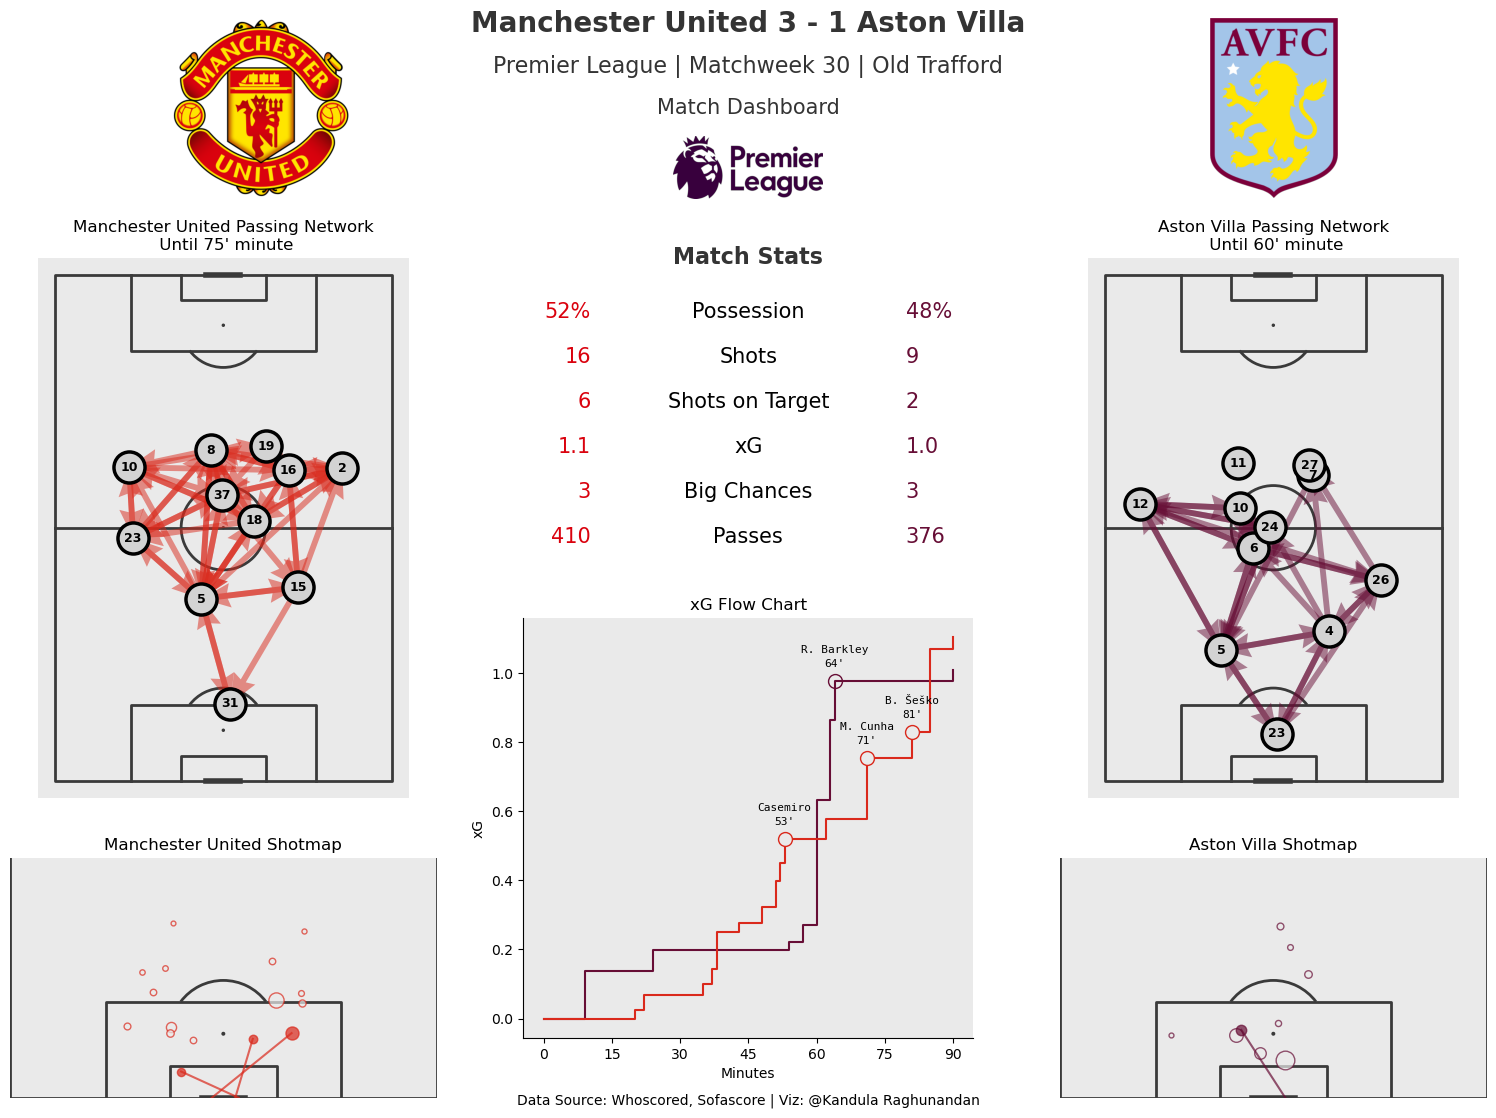

In [50]:
fig = plt.figure(figsize=(15,12))

ax1=fig.add_axes([0.25, 0.8, 0.15, 0.15])
team1_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Manchester United.png")
ax1.imshow(team1_img)
ax1.axis("off")

ax2=fig.add_axes([0.6, 0.775, 0.10, 0.10])
league_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")
ax2.imshow(league_img)
ax2.axis("off")

ax3=fig.add_axes([0.925, 0.8, 0.15, 0.15])
team2_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Aston Villa.png")
ax3.imshow(team2_img)
ax3.axis("off")

ax4=fig.add_axes([.15,.3,.3,.45])
create_passnetwork(team1,ax4, "#DA291C")
ax4.set_title("Manchester United Passing Network\n Until 75' minute")

ax5=fig.add_axes([.5,.1,.3,.35])
create_xg_flowchart(df_shots, ax5, "#DA291C", "#670E36")
ax5.set_title("xG Flow Chart")

plt.text(
    0.5, -0.15, "Data Source: Whoscored, Sofascore | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="black"
)

ax6=fig.add_axes([.85,.3,.3,.45])
create_passnetwork(team2,ax6, "#670E36")
ax6.set_title("Aston Villa Passing Network\n Until 60' minute")

ax7=fig.add_axes([.15,.05,.3,.2])
create_shotmap(team1_shots,ax7, "#DA291C")
ax7.set_title("Manchester United Shotmap")

ax8=fig.add_axes([.85,.05,.3,.2])
create_shotmap(team2_shots,ax8, "#670E36")
ax8.set_title("Aston Villa Shotmap")

ax9 = fig.add_axes([.5,.3,.3,.5])
ax9.set_facecolor("#f7f7f7")
ax9.axis("off")

ax9.text(0.5, 0.9, "Match Stats", ha="center", va="center",
         fontsize=16, fontweight="bold",color="#343434")

labels = ["Possession", "Shots", "Shots on Target", "xG", "Big Chances", "Passes"]

y_positions = [0.8, 0.725, 0.65, 0.575, 0.50, 0.425]

home_vals = ["52%", 16, 6, 1.10, 3, 410]
away_vals = ["48%", 9, 2, 1.00, 3, 376]

for label, y, n_val, u_val in zip(labels, y_positions, home_vals, away_vals):

    ax9.text(0.5, y, label, ha="center", fontsize=15)
    ax9.text(0.15, y, str(n_val), ha="right", fontsize=15,color="#DA020E")
    ax9.text(0.85, y, str(u_val), ha="left", fontsize=15,color="#670E36")


fig.text(0.65, 0.945, "Manchester United 3 - 1 Aston Villa", fontsize=20, fontweight='bold', color='#343434', ha="center", va="center")
fig.text(0.65, 0.91, "Premier League | Matchweek 30 | Old Trafford", fontsize=16, color='#343434', ha="center", va="center")
fig.text(0.65, 0.875, "Match Dashboard", fontsize=15, color='#343434', ha="center", va="center" )


fig.savefig("C:/Users/K Raghunandan/Analyst/Matches/Manchester United 3-1 Aston Villa - Premier League 2025_2026 Live_files/New folder/match_dashboard.png", bbox_inches='tight')